In [ ]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [64, 64 ,64 ,64],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
X_pre cells: (3026, 20)
X_post cells: (3026, 20)
(2420, 20)
(606, 20)
(2420, 20)
(606, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.05162262759745905
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-3711248.7500 g_loss=4308849.0000 | train mmd=0.1194 | test_mmd=0.8035
[CellOT] epoch=50 f_loss=-833.0084 g_loss=188.3626 | train mmd=0.7705 | test_mmd=1.3087
[CellOT] epoch=100 f_loss=-310.2260 g_loss=410.9702 | train mmd=1.0892 | test_mmd=0.4525
[CellOT] epoch=150 f_loss=-539.5929 g_loss=601.9593 | train mmd=1.0342 | test_mmd=0.4038
[CellOT] epoch=200 f_loss=-632.7882 g_loss=750.5660 | train mmd=0.8232 | test_mmd=0.3115
[CellOT] epoch=250 f_loss=-905.5563 g_loss=960.3988 | train mmd=0.9845 | test_mmd=0.3211
[CellOT] epoch=300 f_loss=-774.8613 g_loss=1053.6223 | train mmd=0.4470 | test_mmd=0.2048
[CellOT] epoch=350 f_loss=-1104.7125 g_loss=1341.5306 | train mmd=0.8712 | test_mmd=0.2429
[CellOT] epoch=400 f_loss=-1273.2632 g_loss=1473.2087 | train mmd=0.9551 | test_mmd=0.2471
[CellOT] epoch=450 f_loss=-1374.7203 g_loss=1634.8203 | train mmd=0.9478 | test_mmd=0.2247
[CellOT] epoch=500 f_loss=-1500.1665 g_loss=1812.8491 | train mmd=0.9645 | test_mmd=0.2121
[CellOT

Run 0 metrics: {'mmd2_gamma_median': 0.05048895384609753, 'mmd2_gamma_0.5': 0.40183343459039045, 'mmd2_gamma_1.0': 0.5267122524272445, 'wasserstein_distance': 1.5104203871379596, 'R2_feature_means': 0.9334617192053316}
**************** Run: 1 ****************


...

[CellOT] epoch=50 f_loss=267.3444 g_loss=239.0335 | train mmd=1.0984 | test_mmd=0.4770
[CellOT] epoch=100 f_loss=-408.4763 g_loss=498.8193 | train mmd=1.1003 | test_mmd=0.4439
[CellOT] epoch=150 f_loss=-527.1819 g_loss=632.3821 | train mmd=0.7694 | test_mmd=0.3385
[CellOT] epoch=200 f_loss=-867.6202 g_loss=973.2981 | train mmd=0.9836 | test_mmd=0.3370
[CellOT] epoch=250 f_loss=-1084.7754 g_loss=1124.6013 | train mmd=1.0089 | test_mmd=0.3114
[CellOT] epoch=300 f_loss=-1064.8107 g_loss=1054.4296 | train mmd=0.8010 | test_mmd=0.2282
[CellOT] epoch=350 f_loss=-1314.7800 g_loss=1532.6914 | train mmd=0.9754 | test_mmd=0.2576
[CellOT] epoch=400 f_loss=-1214.6750 g_loss=1654.1409 | train mmd=0.6401 | test_mmd=0.1879
[CellOT] epoch=450 f_loss=-1599.7610 g_loss=1731.5620 | train mmd=0.9562 | test_mmd=0.2167
[CellOT] epoch=500 f_loss=-379.4892 g_loss=1737.3503 | train mmd=0.2323 | test_mmd=0.4748
[CellOT] epoch=550 f_loss=-1489.8427 g_loss=2002.0403 | train mmd=0.8026 | test_mmd=0.1566
[CellOT] e

Run 8 metrics: {'mmd2_gamma_median': 0.023672708505664275, 'mmd2_gamma_0.5': 0.2183586559247176, 'mmd2_gamma_1.0': 0.3423260496624505, 'wasserstein_distance': 1.5564991837948456, 'R2_feature_means': 0.9608458246834212}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=206.3362 g_loss=224.3822 | train mmd=1.0996 | test_mmd=0.4696
[CellOT] epoch=100 f_loss=-374.6874 g_loss=453.0627 | train mmd=1.0990 | test_mmd=0.4300
[CellOT] epoch=150 f_loss=-545.1318 g_loss=593.6744 | train mmd=0.8501 | test_mmd=0.3390
[CellOT] epoch=200 f_loss=-767.4663 g_loss=877.6129 | train mmd=0.9503 | test_mmd=0.3311
[CellOT] epoch=250 f_loss=-1005.4695 g_loss=1121.4001 | train mmd=1.0348 | test_mmd=0.3259
[CellOT] epoch=300 f_loss=-1169.2090 g_loss=1316.5654 | train mmd=1.0376 | test_mmd=0.2967
[CellOT] epoch=350 f_loss=-1232.0183 g_loss=1438.5402 | train mmd=1.0044 | test_mmd=0.2597
[CellOT] epoch=400 f_loss=-1412.2026 g_loss=1650.6383 | train mmd=1.0155 | test_mmd=0.2495
[CellOT] epoch=450 f_loss=-1407.8982 g_loss=1779.7078 | train mmd=0.8563 | test_mmd=0.1877
[CellOT] epoch=500 f_loss=-1070.4270 g_loss=1867.9447 | train mmd=0.5398 | test_mmd=0.1142
[CellOT] epoch=550 f_loss=-1505.2593 g_loss=1988.9412 | train mmd=0.8993 | test_mmd=0.1594
[CellOT] 

Run 9 metrics: {'mmd2_gamma_median': 0.15868687203566734, 'mmd2_gamma_0.5': 0.5510471192753064, 'mmd2_gamma_1.0': 0.5198928655391812, 'wasserstein_distance': 1.8520064378430123, 'R2_feature_means': 0.5120801398631696}
                        mean     std
mmd2_gamma_median     0.0995  0.1007
mmd2_gamma_0.5        0.3963  0.2855
mmd2_gamma_1.0        0.4481  0.2335
wasserstein_distance  1.6802  0.3099
R2_feature_means      0.7972  0.2037


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


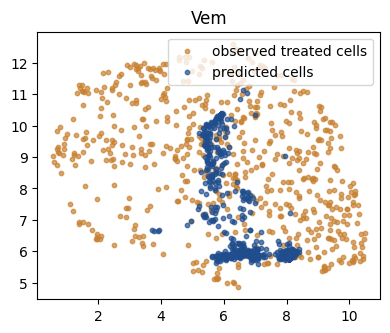

In [6]:
drug = "Vem"
X_pre, X_post = prepare_pair_from_mat('COLO858', 'DMSO','24h', drug, '72h')
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre, X_post, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

In [10]:
drug = "Vem"
X_pre, X_post = prepare_pair_from_mat('WM902B', 'DMSO','24h', drug, '72h')
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre, X_post, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
X_pre cells: (5690, 20)
X_post cells: (5690, 20)
(4552, 20)
(1138, 20)
(4552, 20)
(1138, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.06456030933401641
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-3355624.0000 g_loss=3746488.5000 | train mmd=0.1601 | test_mmd=0.7867
[CellOT] epoch=50 f_loss=333.7708 g_loss=222.1668 | train mmd=1.0116 | test_mmd=0.3859
[CellOT] epoch=100 f_loss=-353.9976 g_loss=380.7114 | train mmd=1.0782 | test_mmd=0.3928
[CellOT] epoch=150 f_loss=-553.4442 g_loss=602.5024 | train mmd=0.9788 | test_mmd=0.3278
[CellOT] epoch=200 f_loss=-747.8425 g_loss=769.8306 | train mmd=0.9830 | test_mmd=0.3216
[CellOT] epoch=250 f_loss=-1222.3127 g_loss=875.1893 | train mmd=0.4355 | test_mmd=0.3517
[CellOT] epoch=300 f_loss=-1021.9438 g_loss=987.0919 | train mmd=0.9042 | test_mmd=0.2553
[CellOT] epoch=350 f_loss=-1007.6368 g_loss=1563.5920 | train mmd=0.7365 | test_mmd=0.2038
[CellOT] epoch=400 f_loss=-1224.8462 g_loss=1320.4329 | train mmd=0.7786 | test_mmd=0.1890
[CellOT] epoch=450 f_loss=-1439.9064 g_loss=1574.4694 | train mmd=0.8283 | test_mmd=0.1974
[CellOT] epoch=500 f_loss=-1539.9265 g_loss=1761.7930 | train mmd=0.8322 | test_mmd=0.1846
[CellOT

Run 0 metrics: {'mmd2_gamma_median': 0.0228316173429175, 'mmd2_gamma_0.5': 0.1774883102596979, 'mmd2_gamma_1.0': 0.2762745201154747, 'wasserstein_distance': 1.2717783514075056, 'R2_feature_means': 0.9828502127731991}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=-3013546.5000 g_loss=3396041.2500 | train mmd=0.1601 | test_mmd=0.7867
[CellOT] epoch=50 f_loss=365.9742 g_loss=315.4385 | train mmd=1.0206 | test_mmd=0.3872
[CellOT] epoch=100 f_loss=-372.9450 g_loss=414.0101 | train mmd=1.0855 | test_mmd=0.3904
[CellOT] epoch=150 f_loss=-601.5657 g_loss=647.3611 | train mmd=0.9846 | test_mmd=0.3338
[CellOT] epoch=200 f_loss=-831.6998 g_loss=855.2887 | train mmd=0.8911 | test_mmd=0.2775
[CellOT] epoch=250 f_loss=-1025.2926 g_loss=979.8942 | train mmd=0.8998 | test_mmd=0.2580
[CellOT] epoch=300 f_loss=-1238.6202 g_loss=1361.9333 | train mmd=0.9295 | test_mmd=0.2640
[CellOT] epoch=350 f_loss=-1427.1322 g_loss=1484.4691 | train mmd=0.7667 | test_mmd=0.2231
[CellOT] epoch=400 f_loss=-1586.4211 g_loss=1714.5986 | train mmd=0.7917 | test_mmd=0.1954
[CellOT] epoch=450 f_loss=-1727.8186 g_loss=1961.0310 | train mmd=0.7887 | test_mmd=0.1891
[CellOT] epoch=500 f_loss=-1766.9767 g_loss=2613.6235 | train mmd=0.7478 | test_mmd=0.1675
[CellO

Run 8 metrics: {'mmd2_gamma_median': 0.03163042469378596, 'mmd2_gamma_0.5': 0.08549024412434392, 'mmd2_gamma_1.0': 0.12208553532097177, 'wasserstein_distance': 1.075354688293289, 'R2_feature_means': 0.9569547094893588}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-2063642.7500 g_loss=2226211.5000 | train mmd=0.1601 | test_mmd=0.7867
[CellOT] epoch=50 f_loss=324.8153 g_loss=660.0584 | train mmd=0.8867 | test_mmd=0.3684
[CellOT] epoch=100 f_loss=-395.8270 g_loss=443.9370 | train mmd=1.0701 | test_mmd=0.3818
[CellOT] epoch=150 f_loss=-653.6917 g_loss=705.6902 | train mmd=0.8551 | test_mmd=0.2672
[CellOT] epoch=200 f_loss=-785.4043 g_loss=837.3347 | train mmd=0.8421 | test_mmd=0.2496
[CellOT] epoch=250 f_loss=-1115.4060 g_loss=1107.8623 | train mmd=0.9260 | test_mmd=0.2651
[CellOT] epoch=300 f_loss=-1269.4304 g_loss=1370.5396 | train mmd=0.8579 | test_mmd=0.2262
[CellOT] epoch=350 f_loss=-1506.0884 g_loss=1576.3849 | train mmd=0.8286 | test_mmd=0.2076
[CellOT] epoch=400 f_loss=-1602.0137 g_loss=1734.2954 | train mmd=0.7390 | test_mmd=0.1743
[CellOT] epoch=450 f_loss=-1803.5212 g_loss=2083.9075 | train mmd=0.7125 | test_mmd=0.1591
[CellOT] epoch=500 f_loss=-1917.6194 g_loss=2236.3462 | train mmd=0.7393 | test_mmd=0.1585
[Cell

Run 9 metrics: {'mmd2_gamma_median': 0.10739596174711519, 'mmd2_gamma_0.5': 0.38911870801195236, 'mmd2_gamma_1.0': 0.4342716317370062, 'wasserstein_distance': 1.4914037240985916, 'R2_feature_means': 0.815647696031292}
                        mean     std
mmd2_gamma_median     0.0443  0.0394
mmd2_gamma_0.5        0.1692  0.1104
mmd2_gamma_1.0        0.2175  0.1323
wasserstein_distance  1.2233  0.2653
R2_feature_means      0.9295  0.0830


AttributeError: 'DummyProcess' object has no attribute 'terminate'

Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
X_pre cells: (2677, 20)
X_post cells: (2677, 20)
(2141, 20)
(536, 20)
(2141, 20)
(536, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.10487158680337198
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-4652797.0000 g_loss=5776148.0000 | train mmd=0.1318 | test_mmd=0.6987
[CellOT] epoch=50 f_loss=269.4297 g_loss=1047.7224 | train mmd=0.6801 | test_mmd=0.2498
[CellOT] epoch=100 f_loss=-113.9228 g_loss=345.6044 | train mmd=0.7146 | test_mmd=0.1999
[CellOT] epoch=150 f_loss=-320.9928 g_loss=456.1716 | train mmd=0.5992 | test_mmd=0.1435
[CellOT] epoch=200 f_loss=-429.0464 g_loss=578.6300 | train mmd=0.4610 | test_mmd=0.0924
[CellOT] epoch=250 f_loss=-496.7188 g_loss=801.4954 | train mmd=0.3231 | test_mmd=0.0917
[CellOT] epoch=300 f_loss=-594.7444 g_loss=769.6606 | train mmd=0.5553 | test_mmd=0.1042
[CellOT] epoch=350 f_loss=-642.6067 g_loss=886.4951 | train mmd=0.3355 | test_mmd=0.0638
[CellOT] epoch=400 f_loss=-650.0369 g_loss=987.3616 | train mmd=0.4782 | test_mmd=0.0762
[CellOT] epoch=450 f_loss=-709.6603 g_loss=1119.4773 | train mmd=0.3206 | test_mmd=0.0450
[CellOT] epoch=500 f_loss=-850.8151 g_loss=1173.0146 | train mmd=0.4670 | test_mmd=0.0697
[CellOT] epoch

Run 0 metrics: {'mmd2_gamma_median': 0.04720326284342091, 'mmd2_gamma_0.5': 0.11202558641149418, 'mmd2_gamma_1.0': 0.18028495574159964, 'wasserstein_distance': 1.3199191192744086, 'R2_feature_means': 0.8965939008851268}
**************** Run: 1 ****************


...

[CellOT] epoch=50 f_loss=474.6043 g_loss=900.6925 | train mmd=0.6858 | test_mmd=0.2071
[CellOT] epoch=100 f_loss=-59.3909 g_loss=372.3025 | train mmd=0.7133 | test_mmd=0.1908
[CellOT] epoch=150 f_loss=-461.1306 g_loss=564.9434 | train mmd=0.7198 | test_mmd=0.2015
[CellOT] epoch=200 f_loss=-611.3236 g_loss=813.3672 | train mmd=0.6388 | test_mmd=0.1452
[CellOT] epoch=250 f_loss=-832.1200 g_loss=799.4951 | train mmd=0.5356 | test_mmd=0.1257
[CellOT] epoch=300 f_loss=-726.9006 g_loss=1378.4517 | train mmd=0.5363 | test_mmd=0.0985
[CellOT] epoch=350 f_loss=-943.7498 g_loss=1153.0740 | train mmd=0.5643 | test_mmd=0.1044
[CellOT] epoch=400 f_loss=-920.7848 g_loss=1824.8516 | train mmd=0.5069 | test_mmd=0.0852
[CellOT] epoch=450 f_loss=-917.0747 g_loss=1273.7422 | train mmd=0.4949 | test_mmd=0.0798
[CellOT] epoch=500 f_loss=-1155.0222 g_loss=1268.0625 | train mmd=0.4650 | test_mmd=0.0719
[CellOT] epoch=550 f_loss=-2561.8147 g_loss=1318.1702 | train mmd=0.3777 | test_mmd=0.0784
[CellOT] epoch=6

Run 8 metrics: {'mmd2_gamma_median': 0.04972045938959724, 'mmd2_gamma_0.5': 0.13109321058229373, 'mmd2_gamma_1.0': 0.20714151318104512, 'wasserstein_distance': 1.5463285963016522, 'R2_feature_means': 0.8148773062668517}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=312.4943 g_loss=1612.6641 | train mmd=0.6148 | test_mmd=0.2516
[CellOT] epoch=100 f_loss=-146.9672 g_loss=310.5554 | train mmd=0.7526 | test_mmd=0.1997
[CellOT] epoch=150 f_loss=-414.0605 g_loss=428.3445 | train mmd=0.6539 | test_mmd=0.1692
[CellOT] epoch=200 f_loss=-408.3353 g_loss=783.7712 | train mmd=0.3626 | test_mmd=0.0924
[CellOT] epoch=250 f_loss=-552.4115 g_loss=797.3804 | train mmd=0.5477 | test_mmd=0.1067
[CellOT] epoch=300 f_loss=-763.6899 g_loss=726.6216 | train mmd=0.4968 | test_mmd=0.0922
[CellOT] epoch=350 f_loss=-719.5190 g_loss=857.0045 | train mmd=0.5056 | test_mmd=0.0843
[CellOT] epoch=400 f_loss=-706.7183 g_loss=1776.5159 | train mmd=0.4702 | test_mmd=0.0828
[CellOT] epoch=450 f_loss=-2932.8159 g_loss=992.7184 | train mmd=0.5398 | test_mmd=0.2578
[CellOT] epoch=500 f_loss=-1738.7175 g_loss=975.9956 | train mmd=0.3218 | test_mmd=0.0905
[CellOT] epoch=550 f_loss=-912.1703 g_loss=4134.1035 | train mmd=0.4061 | test_mmd=0.0613
[CellOT] epoch=600

Run 9 metrics: {'mmd2_gamma_median': 0.2756241886614621, 'mmd2_gamma_0.5': 0.5374148793980765, 'mmd2_gamma_1.0': 0.5414677293700438, 'wasserstein_distance': 1.8026562837088465, 'R2_feature_means': 0.6958805982748926}
                        mean     std
mmd2_gamma_median     0.1122  0.0855
mmd2_gamma_0.5        0.2498  0.1509
mmd2_gamma_1.0        0.3062  0.1303
wasserstein_distance  1.4495  0.1874
R2_feature_means      0.8339  0.0883


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


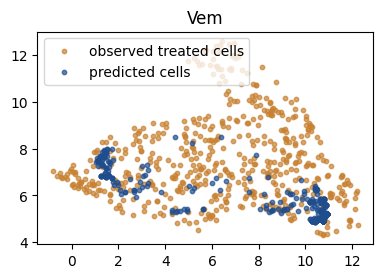

In [5]:
drug = "Vem"
X_pre, X_post = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', drug, '72h')
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]  

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre, X_post, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=2000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)